In [14]:
import jax.numpy as jnp
import sax
import sax.models as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
color = cm.rainbow(np.linspace(0, 1, 10))


# MODELS

In [45]:
#Definimos un modelo de guía dispersiva con los datos obtenidos en las simulaciones
wls_neff = jnp.linspace(1.5, 1.6, 200)
neffs = jnp.asarray([
    2.39852119, 2.39788955, 2.39725789, 2.39662621, 2.39599451,
    2.39536280, 2.39473106, 2.39409931, 2.39346754, 2.39283575,
    2.39220394, 2.39157212, 2.39094027, 2.39030841, 2.38967653,
    2.38904463, 2.38841272, 2.38778078, 2.38714883, 2.38651687,
    2.38588488, 2.38525288, 2.38462087, 2.38398883, 2.38335678,
    2.38272471, 2.38209263, 2.38146053, 2.38082842, 2.38019629,
    2.37956414, 2.37893198, 2.37829980, 2.37766761, 2.37703540,
    2.37640318, 2.37577094, 2.37513869, 2.37450642, 2.37387414,
    2.37324184, 2.37260953, 2.37197721, 2.37134487, 2.37071252,
    2.37008016, 2.36944778, 2.36881539, 2.36818298, 2.36755057,
    2.36691814, 2.36628569, 2.36565324, 2.36502077, 2.36438829,
    2.36375580, 2.36312329, 2.36249078, 2.36185825, 2.36122571,
    2.36059316, 2.35996060, 2.35932803, 2.35869544, 2.35806285,
    2.35743024, 2.35679763, 2.35616500, 2.35553237, 2.35489972,
    2.35426707, 2.35363440, 2.35300173, 2.35236905, 2.35173636,
    2.35110365, 2.35047094, 2.34983823, 2.34920550, 2.34857276,
    2.34794002, 2.34730727, 2.34667451, 2.34604174, 2.34540897,
    2.34477619, 2.34414340, 2.34351060, 2.34287780, 2.34224499,
    2.34161218, 2.34097935, 2.34034653, 2.33971369, 2.33908085,
    2.33844801, 2.33781516, 2.33718230, 2.33654944, 2.33591658,
    2.33528371, 2.33465083, 2.33401795, 2.33338507, 2.33275218,
    2.33211929, 2.33148640, 2.33085350, 2.33022060, 2.32958770,
    2.32895479, 2.32832188, 2.32768897, 2.32705605, 2.32642314,
    2.32579022, 2.32515730, 2.32452438, 2.32389145, 2.32325853,
    2.32262560, 2.32199268, 2.32135975, 2.32072683, 2.32009390,
    2.31946097, 2.31882804, 2.31819512, 2.31756219, 2.31692927,
    2.31629634, 2.31566342, 2.31503050, 2.31439758, 2.31376466,
    2.31313174, 2.31249883, 2.31186592, 2.31123301, 2.31060010,
    2.30996720, 2.30933430, 2.30870140, 2.30806851, 2.30743562,
    2.30680273, 2.30616985, 2.30553698, 2.30490410, 2.30427124,
    2.30363838, 2.30300552, 2.30237267, 2.30173982, 2.30110698,
    2.30047415, 2.29984132, 2.29920850, 2.29857569, 2.29794288,
    2.29731008, 2.29667729, 2.29604450, 2.29541173, 2.29477896,
    2.29414620, 2.29351345, 2.29288070, 2.29224797, 2.29161524,
    2.29098253, 2.29034982, 2.28971713, 2.28908444, 2.28845176,
    2.28781910, 2.28718645, 2.28655380, 2.28592117, 2.28528855,
    2.28465594, 2.28402334, 2.28339076, 2.28275819, 2.28212563,
    2.28149308, 2.28086055, 2.28022803, 2.27959552, 2.27896303,
    2.27833055, 2.27769808, 2.27706563, 2.27643320, 2.27580078,
    2.27516837, 2.27453598, 2.27390361, 2.27327125, 2.27263891,
])

def interp_neff(wl=1.55):
    """
    Interpola neff(wl) siguiendo el ejemplo oficial de SAX:
    se interpola frente a 1 / wl, no directamente frente a wl.

    wl en micras.
    """
    wl = jnp.asarray(wl)

    return jnp.interp(
        1 / wl,
        1 / wls_neff[::-1],
        neffs[::-1],
    )

def wg_disp(
    *,
    wl=1.55,
    length=10.0,
    loss=0.0,
):
    neff = interp_neff(wl)
    phase = 2 * jnp.pi * neff * length / wl
    amplitude = 10 ** (-loss * length / 20)
    transmission = amplitude * jnp.exp(1j * phase)

    return sax.reciprocal({
        ("in0", "out0"): transmission,
    })

def coupler(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi2x2(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi3x3() -> sax.SDict:
    coup = jnp.sqrt(1/3)
    mmi_dict = sax.reciprocal(
        {
            ("in0", "out0"): coup*jnp.exp( 1j* 2*jnp.pi /3),
            ("in0", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in0", "out2"): coup,

            ("in1", "out0"): coup*jnp.exp(-1j*jnp.pi /3),
            ("in1", "out1"): coup,
            ("in1", "out2"): coup*jnp.exp( -1j*jnp.pi /3),

            ("in2", "out0"): coup,
            ("in2", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in2", "out2"): coup*jnp.exp( 1j* 2*jnp.pi /3),

        }
    )

    return mmi_dict

# CIRCUIT

In [46]:

wvltracker, info = sax.circuit(
    netlist={
        "instances": {
            "mmi2x2": "mmi2x2",
            "wvg_u": "wg_disp",
            "wvg_d": "wg_disp",
            "mmi3x3": "mmi3x3",
        },
        "connections": {
            "mmi2x2,out0": "wvg_u,in0",
            "wvg_u,out0": "mmi3x3,in0",
            "mmi2x2,out1": "wvg_d,in0",
            "wvg_d,out0": "mmi3x3,in2",
        },
        "ports": {
            "in0": "mmi2x2,in0",
            "in1": "mmi2x2,in1",
            "out0": "mmi3x3,out0",
            "out1": "mmi3x3,out1",
            "out2": "mmi3x3,out2",
        },
    },
    models={
        "mmi2x2": mmi2x2,
        "wg_disp":wg_disp,
        "mmi3x3" : mmi3x3,
    },
)


<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1271/3187288868.py:24: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta \lambda$ (pm)")


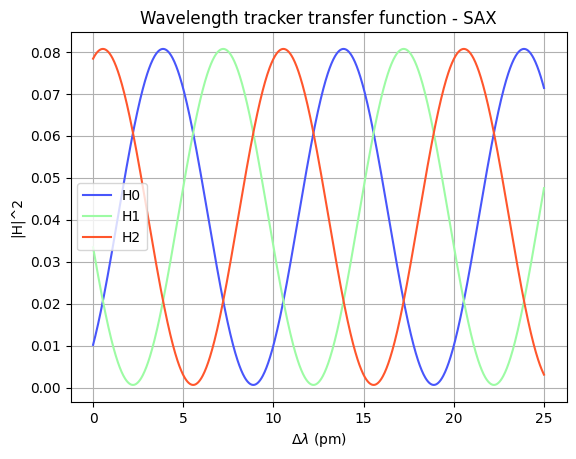

In [54]:
wls = jnp.linspace(1.55000, 1.550025, 1000)
loss_spiral = 10 * np.log10(19) / 56000  # dB/um #FORZADA PARA QUE ENTRE LA MISMA POTENCIA EN LOS DOS BRAZOS DEL MMI 3X3
loss_soi_dB_cm = 2
loss_soi = loss_soi_dB_cm / 10000  # dB/um

test = wvltracker(wl = wls, 
                  wvg_u={"wl":wls, "length": 10, "loss":0},
                  wvg_d={"wl":wls, "length": 56010, "loss":loss_soi},)

h0 = test["in0", "out0"]
h1 = test["in0", "out1"]
h2 = test["in0", "out2"]

H0 = np.abs(h0)**2
H1 = np.abs(h1)**2
H2 = np.abs(h2)**2

wl0 = 1.55
dl_pm = (np.asarray(wls) - wl0) * 1e6  # um -> pm

plt.plot(dl_pm, H0, linestyle = '-', color = color[1], label = 'H0')
plt.plot(dl_pm, H1, linestyle = '-', color = color[5], label = 'H1')
plt.plot(dl_pm, H2, linestyle = '-', color = color[8], label = 'H2')
plt.xlabel("$\Delta \lambda$ (pm)")
plt.ylabel('|H|^2')
plt.title('Wavelength tracker transfer function - SAX')
plt.legend()
plt.grid(True)

plt.show()

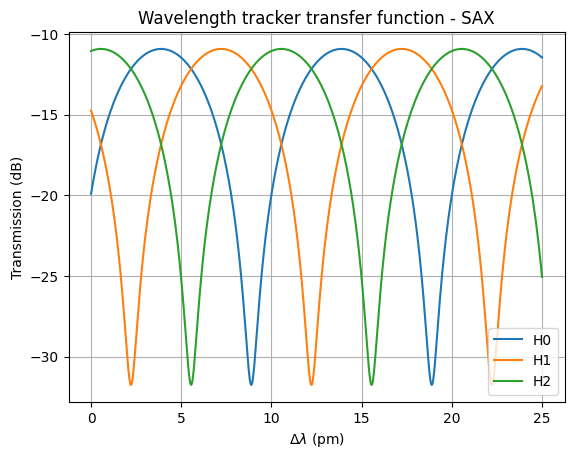

In [55]:
eps = 1e-15

H0_dB = 10 * np.log10(H0 + eps)
H1_dB = 10 * np.log10(H1 + eps)
H2_dB = 10 * np.log10(H2 + eps)


plt.plot(dl_pm, H0_dB, label="H0")
plt.plot(dl_pm, H1_dB, label="H1")
plt.plot(dl_pm, H2_dB, label="H2")

plt.xlabel(r"$\Delta\lambda$ (pm)")
plt.ylabel("Transmission (dB)")
plt.title("Wavelength tracker transfer function - SAX")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(H0)

peak_wls = np.asarray(wls)[peaks]
fsrs_pm = np.diff(peak_wls) * 1e6

print("FSR medio [pm]:", np.mean(fsrs_pm))
print("FSR std [pm]:", np.std(fsrs_pm))

FSR medio [pm]: 10.01001000988655
FSR std [pm]: 1.1102230246251565e-10
